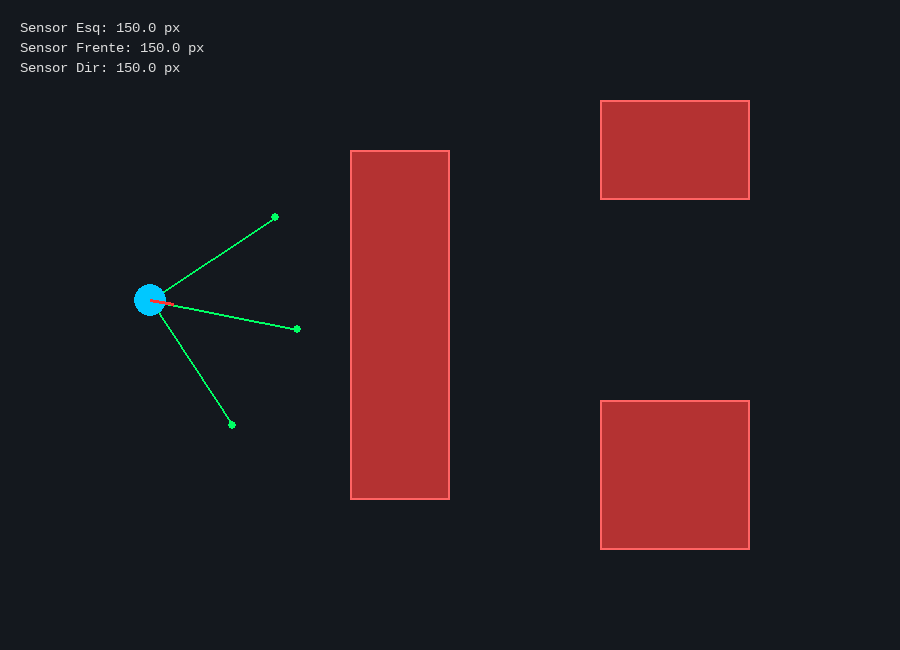

In [3]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"
import pygame
import math
from IPython.display import display
from PIL import Image


def main_colab():
    pygame.init()
    screen = pygame.display.set_mode((900, 650))
    font = pygame.font.SysFont("monospace", 14)

    robot = RaycastDemoRobot(150, 300, 0.0)
    obstacles = [
        pygame.Rect(350, 150, 100, 350),
        pygame.Rect(600, 100, 150, 100),
        pygame.Rect(600, 400, 150, 150)
    ]


    robot.theta = 0.2
    robot.cast_rays(obstacles)

    screen.fill((20, 24, 30))
    for obs in obstacles:
        pygame.draw.rect(screen, (180, 50, 50), obs)
        pygame.draw.rect(screen, (255, 100, 100), obs, 2)

    robot.draw(screen)

    leituras = [f"Sensor {['Esq', 'Frente', 'Dir'][i]}: {dist:5.1f} px" for i, dist in enumerate(robot.sensor_readings)]
    for i, l in enumerate(leituras):
        screen.blit(font.render(l, True, (220, 220, 220)), (20, 20 + i * 20))

    pygame.display.flip()


    view = pygame.surfarray.array3d(screen)
    view = view.transpose([1, 0, 2])
    img_surface = Image.fromarray(view)
    display(img_surface)
    pygame.quit()

main_colab()